# Homework 7: The Newton-Raphson Method

In class we implemented the **bisection method** to find roots of functions. This homework introduces a second root-finding algorithm - the **Newton-Raphson method** - and applies it to the projectile motion problem we studied earlier in the course.

Recall from the in-class module: given a function $f(x)$, a root is a value $x^*$ such that $f(x^*) = 0$.

## Problem 1: Implementing the Newton-Raphson Method

The Newton-Raphson method finds roots by following the tangent line of $f$ at the current guess and using its zero-crossing as the next guess.

Starting from an initial guess $x_0$, each iteration produces a new, improved guess via

$$x_{n+1} = x_n - \frac{f(x_n)}{f'(x_n)}.$$

We stop when the size of the correction $|f(x_n)/f'(x_n)|$ falls below a tolerance `tol`.

![Newton-Raphson iteration](https://upload.wikimedia.org/wikipedia/commons/thumb/8/8c/Newton_iteration.svg/512px-Newton_iteration.svg.png)

![Newton-Raphson animation](https://upload.wikimedia.org/wikipedia/commons/e/e0/NewtonIteration_Ani.gif)

*(Images from [Wikipedia: Newton's method](https://en.wikipedia.org/wiki/Newton%27s_method))*

**Task.** Complete `newton1()` below. It takes the function `f`, its derivative `df`, an initial guess `x`, and a tolerance `tol`. Test it by finding the root of $\sin(x)$ near $x = \pi$.

In [1]:
import numpy as np

def newton1(f, df, x, tol=1e-5):
    """
    Find a root of f using the Newton-Raphson method.
    Parameters
    ----------
    f   : function whose root we seek
    df  : derivative of f
    x   : initial guess
    tol : stop when the correction |f(x)/df(x)| < tol
    """
    while abs(f(x)/df(x)) > tol:
        x -= f(x)/df(x)
    return x

x_init = 3
result = newton1(np.sin, np.cos, x_init)
print(result)

3.141592653300477


## Problem 2: Newton-Raphson Without an Explicit Derivative

Requiring the user to supply `df` is sometimes inconvenient - for complicated functions, the derivative may be tedious to derive analytically. We can instead **approximate the derivative numerically** using a finite difference:

$$f'(x) \approx \frac{f(x + h) - f(x)}{h}$$

for a small step size $h$. This frees the user from having to provide `df` at all.

### Task 1

Complete `newton2()` below. It has the same interface as `newton1()` except that it takes only `f` (no `df`). Compute the derivative numerically inside the function using a finite difference with $h = 10^{-6}$. Test it by finding the root of $\sin(x)$ near $x = \pi$ again - you should get the same answer as before.

In [15]:
def newton2(f, x, tol=1e-5):
    """
    Find a root of f using the Newton-Raphson method with a numerical derivative.
    Parameters
    ----------
    f   : function whose root we seek
    x   : initial guess
    tol : stop when the correction |f(x)/df(x)| < tol
    """
    h = 1e-6
    df = (lambda x:(f(x+h) - f(x)) / h)
    while abs(f(x)/df(x)) > tol:
        print(f(x)/df(x))
        x -= f(x)/df(x)
    return x

# Test: find the root of sin(x) near pi (provide only sin, not cos)
x_init = 3
result = newton2(np.sin, x_init)
print(result)

-0.14254653289656352
0.0009538795963992457
3.1415926533001644


### Task 2

Apply `newton2()` to the projectile problem from class. A projectile is launched at $v_0 = 30$ m/s and $\theta = 30°$ above the ground, with $g = 9.8$ m/s$^2$ and linear drag coefficient $b = 1$ s$^{-1}$. The landing distance $R$ satisfies

$$f(R) = \frac{R}{v_{x0}}\left(v_{z0} + \frac{g}{b}\right) + \frac{g}{b^2}\ln\!\left(1 - \frac{b R}{v_{x0}}\right) = 0.$$

Use `newton2()` with an initial guess near $R = 24$ m to find the landing distance. The answer should be near 23.29 m.

In [17]:
import matplotlib.pyplot as plt

g = 9.8
b = 1
angle = 30  # degrees
v0x = 30 * np.cos(angle / 180 * np.pi)
v0z = 30 * np.sin(angle / 180 * np.pi)

def f(R):
    return R / v0x * (v0z + g/b) + g/b**2 * np.log(1 - b*R/v0x)

R_init = 24
result = newton2(f, R_init)
print(f'Landing distance: {result:.4f} m')

0.5796870115260123
0.12265816613077411
0.0040395132746385365
Landing distance: 23.2936 m


### Task 3

You may have noticed that `newton2()` is sensitive to the initial guess for this problem. It works well for $R_0 \approx 21$–$25$ m, but crashes or diverges outside this range.

To understand why, plot $f(R)$ over the range $R \in [0, 27]$ m. Then, following the example sketch below, trace through the first one or two iterations of the Newton-Raphson method for a starting guess of $R_0 > 25$ m and for $R_0 < 21$ m.

![Example sketch](newton_example_sketch.png)

In a markdown cell below each plot, explain in 2–3 sentences:
1. Why does the algorithm fail when started from $R_0 > 25$ m?
2. Why does the algorithm fail when started from $R_0 < 21$ m?

/var/folders/0d/3vfpxd9x3klczjccgkvz1xth0000gn/T/ipykernel_46885/2413429979.py:10: RuntimeWarning: invalid value encountered in log
  return R / v0x * (v0z + g/b) + g/b**2 * np.log(1 - b*R/v0x)


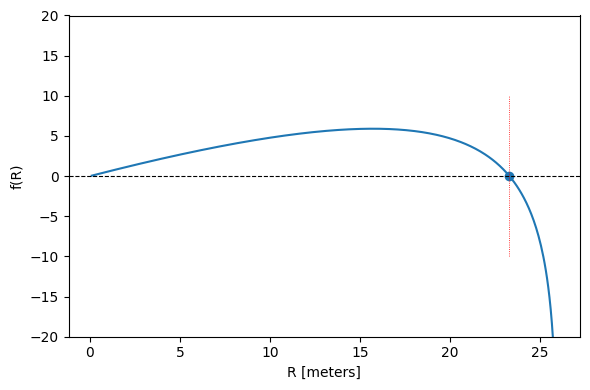

In [19]:
# Plot f(R) and sketch the Newton-Raphson iterations
R_vals = np.linspace(0.1, 27, 400)
f_vals = f(R_vals)

fig, ax = plt.subplots(1, figsize=(6, 4))
ax.plot(R_vals, f_vals)           # hint: plot f(R) vs R
ax.axhline(0, color='k', linewidth=0.8, linestyle='--')
ax.vlines(result, -10, 10, linewidth=0.6, linestyles=':', colors='red')
ax.scatter(result, 0)
ax.set_xlabel('R [meters]')
ax.set_ylabel('f(R)')
ax.set_ylim(-20, 20)
plt.tight_layout()
plt.show()

**Why does the algorithm fail for $R_0 > 25$ m?**

The step size is small (because the line is steep at that point) causing the loop to end prematurely, despite still being far from the zero.

**Why does the algorithm fail for $R_0 < 21$ m?**

The algorithm tends toward the zero at $R=0$.